# Facet, notebook 1: aspect-based sentiment with DeBERTa-v3-base

Aspect-based sentiment as sentence-pair classification: `(aspect, sentence)` to negative / neutral / positive.
Data: SemEval-2014 Task 4 (restaurants + laptops). Training on a Kaggle GPU with fp16.
This notebook trains, evaluates, calibrates, explains (SHAP) and pushes the model to the Hugging Face Hub.

In [2]:
!pip install -q -U transformers datasets accelerate sentencepiece seaborn shap mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 67.8 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 498.0/498.0 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 85.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 93.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

In [3]:
import os, json, numpy as np, pandas as pd, torch
from huggingface_hub import login, HfApi
from kaggle_secrets import UserSecretsClient

login(UserSecretsClient().get_secret("HF_TOKEN"))     
api = HfApi()

LABELS = ["negative", "neutral", "positive"]
l2i = {l: i for i, l in enumerate(LABELS)}

def ece(conf, correct, bins=10):
    edges = np.linspace(0, 1, bins + 1); total = 0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            total += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return total

REPO = "sy12ssss/absa-deberta-v3"
MODEL = "microsoft/deberta-v3-base"
REPORT_TO = "mlflow"
os.makedirs("results", exist_ok=True)

## 1. Data

In [4]:
from datasets import load_dataset

frames = []
for repo, dom in [("tomaarsen/setfit-absa-semeval-restaurants", "restaurant"),
                  ("tomaarsen/setfit-absa-semeval-laptops", "laptop")]:
    ds = load_dataset(repo)
    for split in ds.keys():
        df = ds[split].to_pandas()
        lab = ds[split].features.get("label")
        if hasattr(lab, "names"):
            df["label"] = df["label"].map(dict(enumerate(lab.names)))
        df["domain"] = dom
        frames.append(df)
    print(dom, {k: len(v) for k, v in ds.items()})

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/147k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/46.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3693 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1134 [00:00<?, ? examples/s]

...

data/train-00000-of-00001.parquet:   0%|          | 0.00/117k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/30.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2358 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/654 [00:00<?, ? examples/s]

laptop {'train': 2358, 'test': 654}


In [5]:
from sklearn.model_selection import GroupShuffleSplit

full_df = pd.concat(frames, ignore_index=True)
full_df = full_df.rename(columns={c: "aspect" for c in ("span", "term", "aspect_term") if c in full_df.columns})
full_df["label"] = full_df["label"].astype(str).str.strip().str.lower()
full_df = full_df[full_df["label"].isin(l2i)].copy()          
full_df["label"] = full_df["label"].map(l2i)
full_df = (full_df[["text", "aspect", "label", "domain"]]
           .drop_duplicates(subset=["text", "aspect"]).reset_index(drop=True))
print("Total (aspect, sentence) pairs:", len(full_df))
assert len(full_df) == 5822, "Unexpected pair count: check the data cell output"

def group_split(df, test_size, seed=42):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    a, b = next(gss.split(df, groups=df["text"]))          
    return df.iloc[a].reset_index(drop=True), df.iloc[b].reset_index(drop=True)

train_df, tmp_df = group_split(full_df, 0.2)
val_df, test_df = group_split(tmp_df, 0.5)
print("train/val/test:", len(train_df), len(val_df), len(test_df))   

Total (aspect, sentence) pairs: 5822
train/val/test: 4652 582 588


## 2. Tokenize and fine-tune

In [6]:
from datasets import Dataset
from sklearn.metrics import f1_score, accuracy_score
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments,
                          Trainer, DataCollatorWithPadding, set_seed)

tok = AutoTokenizer.from_pretrained(MODEL)

def to_ds(df):
    d = df[["text", "aspect", "label"]].reset_index(drop=True)
    return Dataset.from_pandas(d).map(
        lambda b: tok(b["aspect"], b["text"], truncation=True, max_length=128), batched=True)

train_ds, val_ds, test_ds = map(to_ds, (train_df, val_df, test_df))

set_seed(42)
os.environ["MLFLOW_EXPERIMENT_NAME"] = "absa-sentiment"
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL, num_labels=3, id2label=dict(enumerate(LABELS)), label2id=l2i).float()   
print("param dtype:", next(model.parameters()).dtype)

def compute_metrics(p):
    pr = p.predictions.argmax(-1)
    return {"accuracy": accuracy_score(p.label_ids, pr), "f1_macro": f1_score(p.label_ids, pr, average="macro")}

steps_per_epoch = -(-len(train_ds) // 16)
args = TrainingArguments(
    output_dir="out", learning_rate=2e-5,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    num_train_epochs=4, warmup_steps=int(0.1 * steps_per_epoch * 4), weight_decay=0.01,
    fp16=True, eval_strategy="epoch", save_strategy="epoch",
    load_best_model_at_end=True, metric_for_best_model="f1_macro",
    save_total_limit=1, report_to=REPORT_TO, seed=42)

trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=val_ds,
                  data_collator=DataCollatorWithPadding(tok), compute_metrics=compute_metrics)
trainer.train()

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

Map:   0%|          | 0/4652 [00:00<?, ? examples/s]

Map:   0%|          | 0/582 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1164, training_loss=0.3847733871224, metrics={'train_runtime': 190.0262, 'train_samples_per_second': 97.923, 'train_steps_per_second': 6.125, 'total_flos': 496900656050760.0, 'train_loss': 0.3847733871224, 'epoch': 4.0})

## 3. Evaluation on the held-out test set

test size: 588
              precision    recall  f1-score   support

    negative     0.8068    0.7978    0.8023       178
     neutral     0.6429    0.6372    0.6400       113
    positive     0.9133    0.9226    0.9179       297

    accuracy                         0.8299       588
   macro avg     0.7877    0.7858    0.7867       588
weighted avg     0.8291    0.8299    0.8295       588



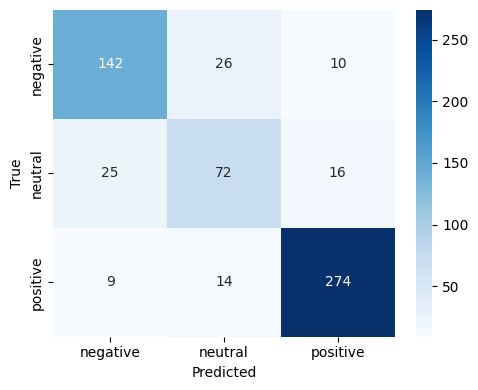

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

out = trainer.predict(test_ds)
y_true, logits = out.label_ids, out.predictions
y_pred = logits.argmax(-1)
print("test size:", len(y_true))

report = classification_report(y_true, y_pred, target_names=LABELS, digits=4)
print(report)
open("results/classification_report.txt", "w").write(report)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=200)
plt.show()

## 4. Calibration: ECE, entropy, temperature scaling

The temperature is fitted on the validation set and reported on the test set.

In [8]:
from scipy.special import softmax, log_softmax
from scipy.optimize import minimize_scalar

val_out = trainer.predict(val_ds)
val_logits, val_y = val_out.predictions, val_out.label_ids

nll = lambda T: -log_softmax(val_logits / T, axis=-1)[np.arange(len(val_y)), val_y].mean()
T = float(minimize_scalar(nll, bounds=(0.5, 5.0), method="bounded").x)

correct = (y_pred == y_true).astype(float)
p0, p1 = softmax(logits, -1), softmax(logits / T, -1)
ent = lambda p: -(p * np.log(p + 1e-12)).sum(-1) / np.log(3)      

print("T =", round(T, 3), "(T > 1 means the model was overconfident)")
print("Accuracy:", round(correct.mean(), 4), "| mean confidence before/after:",
      round(p0.max(-1).mean(), 4), round(p1.max(-1).mean(), 4))
print("ECE before/after:", round(ece(p0.max(-1), correct), 4), round(ece(p1.max(-1), correct), 4))
print("Mean entropy after scaling, correct vs wrong:",
      ent(p1)[correct == 1].mean().round(3), ent(p1)[correct == 0].mean().round(3))
json.dump({"temperature": T}, open("results/calibration.json", "w"))

T = 2.186 (T > 1 means the model was overconfident)
Accuracy: 0.8299 | mean confidence before/after: 0.9542 0.8463
ECE before/after: 0.1242 0.0556
Mean entropy after scaling, correct vs wrong: 0.381 0.631


## 5. Explainability with SHAP

Token importance with the aspect held fixed. The same sentence gives different explanations per aspect.

In [9]:
import shap
from IPython.display import HTML, display

model = trainer.model.eval()

def make_predict(aspect):
    def f(texts):
        e = tok([aspect] * len(texts), list(texts), return_tensors="pt",
                padding=True, truncation=True, max_length=128).to(model.device)
        with torch.no_grad():
            return torch.softmax(model(**e).logits, -1).cpu().numpy()
    return f

def explain(text, aspect):
    explainer = shap.Explainer(make_predict(aspect), shap.maskers.Text(tok), output_names=LABELS)
    sv = explainer([text])
    pred = int(make_predict(aspect)([text]).argmax())
    html = shap.plots.text(sv[0], display=False)
    tokens = [{"token": t, "score": float(s)} for t, s in zip(sv.data[0], sv.values[0][:, pred])]
    return html, tokens, LABELS[pred]

text = "The food was great but the service was painfully slow."
for aspect in ["service", "food"]:
    html, tokens, pred = explain(text, aspect)
    print(aspect, "->", pred, "| top tokens:",
          [(t["token"], round(t["score"], 3)) for t in sorted(tokens, key=lambda t: -abs(t["score"]))[:5]])
    open(f"results/shap_{aspect}.html", "w").write(html)
display(HTML(html))

service -> negative | top tokens: [(' painfully', 0.514), (' slow', 0.438), (' the', 0.081), (' service', -0.065), (' was', 0.018)]
food -> positive | top tokens: [(' great', 0.784), (' service', 0.173), (' but', 0.164), ('The', -0.158), (' painfully', -0.149)]


## 6. Push to the Hugging Face Hub

In [10]:
OUT = "deberta_model"
trainer.model.save_pretrained(OUT); tok.save_pretrained(OUT)
cp = f"deberta_model/tokenizer_config.json"; c = json.load(open(cp))
if isinstance(c.get("extra_special_tokens"), list):          
    c["extra_special_tokens"] = {}; json.dump(c, open(cp, "w"), indent=2)
api.create_repo(REPO, exist_ok=True)
api.upload_folder(folder_path=OUT, repo_id=REPO)
for f in ["results/calibration.json", "results/classification_report.txt", "results/confusion_matrix.png"]:
    api.upload_file(path_or_fileobj=f, path_in_repo=os.path.basename(f), repo_id=REPO)
AutoTokenizer.from_pretrained(REPO, force_download=True)
print("pushed and reloaded OK:", "https://huggingface.co/" + REPO)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/496 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/496 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/496 [00:00<?, ?B/s]

pushed and reloaded OK: https://huggingface.co/sy12ssss/absa-deberta-v3
